# MSCS-634: Advanced Big Data and Data Mining
### Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms
**Name:** Samia Zaman

**Dataset:** Wine Dataset from `sklearn.datasets` (178 samples, 13 chemical-analysis
features, 3 cultivar classes). The dataset is used unsupervised (class labels are only
used afterward to score how well each clustering recovered the true groups).


## Step 1: Load and Prepare the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, pairwise_distances

import kmedoids

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

wine = load_wine()
X_raw = wine.data
y_true = wine.target

df = pd.DataFrame(X_raw, columns=wine.feature_names)
df["target"] = y_true
df["target_name"] = df["target"].map(dict(enumerate(wine.target_names)))
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


**Feature details:**

In [2]:
print(f"Number of samples: {X_raw.shape[0]}")
print(f"Number of features: {X_raw.shape[1]}")
print("\nFeature names:")
for name in wine.feature_names:
    print(f" - {name}")


Number of samples: 178
Number of features: 13

Feature names:
 - alcohol
 - malic_acid
 - ash
 - alcalinity_of_ash
 - magnesium
 - total_phenols
 - flavanoids
 - nonflavanoid_phenols
 - proanthocyanins
 - color_intensity
 - hue
 - od280/od315_of_diluted_wines
 - proline


**Class distribution:**

In [3]:
class_counts = df["target_name"].value_counts()
class_counts


target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

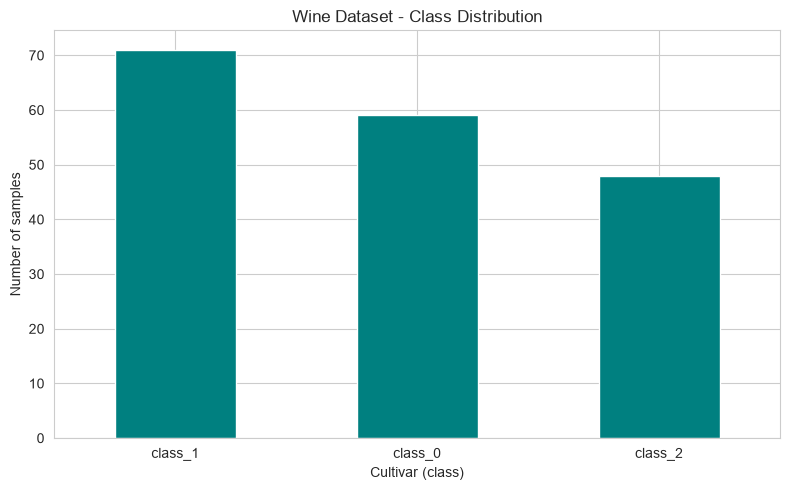

In [4]:
plt.figure()
class_counts.plot(kind="bar", color="teal")
plt.xlabel("Cultivar (class)")
plt.ylabel("Number of samples")
plt.title("Wine Dataset - Class Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Notes:** The dataset has 178 samples and 13 numeric features (chemical measurements
like alcohol content, malic acid, flavanoids, color intensity, etc.), grouped into 3
cultivar classes. The classes are reasonably balanced (59 / 71 / 48 samples), so no
class is negligibly small.


### Standardization (z-score normalization)

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Mean of scaled features (should be ~0): {X.mean(axis=0).round(2)}")
print(f"Std of scaled features (should be ~1): {X.std(axis=0).round(2)}")


Mean of scaled features (should be ~0): [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]
Std of scaled features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Notes:** The 13 features are on very different scales (e.g. `proline` is in the
hundreds while `hue` is under 2), so both K-Means and K-Medoids would otherwise be
dominated by whichever feature happens to have the largest numeric range. Z-score
standardization (`StandardScaler`) rescales every feature to mean 0 and standard
deviation 1 so all features contribute comparably to the distance calculations used
by clustering.


## Step 2: Implement K-Means Clustering

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

kmeans_silhouette = silhouette_score(X, kmeans_labels)
kmeans_ari = adjusted_rand_score(y_true, kmeans_labels)

print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"K-Means Adjusted Rand Index: {kmeans_ari:.4f}")


K-Means Silhouette Score: 0.2849
K-Means Adjusted Rand Index: 0.8975


**Notes:** `k=3` was used since the Wine dataset has 3 known cultivars. The Silhouette
Score measures how well-separated the clusters are using only the feature data (no
labels), while the Adjusted Rand Index (ARI) compares the cluster assignments against
the true cultivar labels, so it can only be computed because we happen to have ground
truth here.


## Step 3: Implement K-Medoids Clustering

**Note on library choice:** the "standard" `sklearn_extra.cluster.KMedoids` class
depends on Python's `distutils` module, which was removed in Python 3.12+, so it fails
to import on this environment (Python 3.14). Instead this notebook uses the
[`kmedoids`](https://pypi.org/project/kmedoids/) package, which implements the
FasterPAM algorithm - a modern, actively-maintained, and faster exact implementation
of the same K-Medoids idea (partition around medoids: each cluster is represented by
an actual data point, the medoid, rather than a computed mean). It operates on a
precomputed pairwise distance matrix.


In [7]:
distance_matrix = pairwise_distances(X, metric="euclidean")

kmedoids_result = kmedoids.fasterpam(distance_matrix, medoids=3, random_state=42)
kmedoids_labels = np.array(kmedoids_result.labels)
kmedoids_medoid_indices = np.array(kmedoids_result.medoids)

kmedoids_silhouette = silhouette_score(X, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y_true, kmedoids_labels)

print(f"K-Medoids Silhouette Score: {kmedoids_silhouette:.4f}")
print(f"K-Medoids Adjusted Rand Index: {kmedoids_ari:.4f}")


K-Medoids Silhouette Score: 0.2676
K-Medoids Adjusted Rand Index: 0.7411


**Notes:** Just as in Step 2, `k=3` medoids were used. The medoids returned are indices
of actual samples in the dataset (unlike K-Means centroids, which are computed means
that may not correspond to any real sample).


## Step 4: Visualize and Compare Results

Since the standardized dataset has 13 dimensions, PCA is used to project it down to 2
principal components purely for visualization. Clustering itself was performed on the
full 13-dimensional standardized data above - PCA is not used until this plotting step.


In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.3f}")

# Project K-Means centroids into the same PCA space
kmeans_centroids_pca = pca.transform(kmeans.cluster_centers_)

# K-Medoids medoids are real data points, so just look up their PCA coordinates
kmedoids_medoids_pca = X_pca[kmedoids_medoid_indices]


Explained variance ratio (PC1, PC2): [0.362 0.192]
Total variance captured by 2 components: 0.554


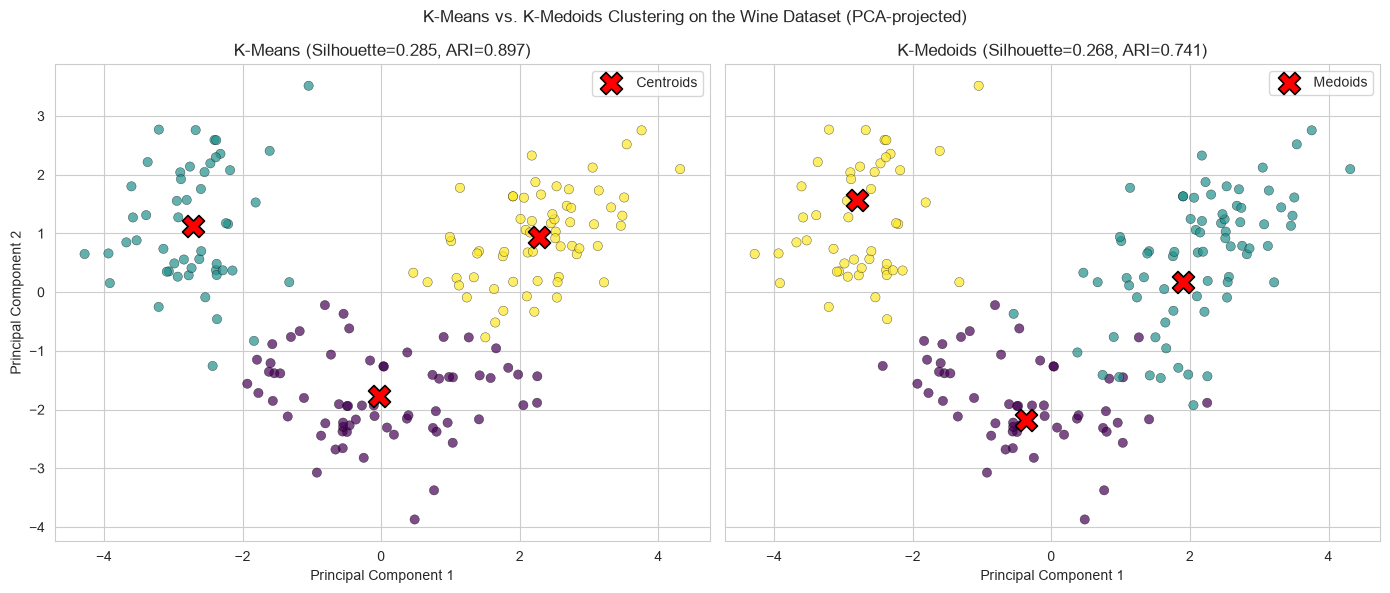

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

scatter_kwargs = dict(cmap="viridis", alpha=0.7, edgecolor="k", linewidth=0.3, s=45)

# --- K-Means panel ---
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, **scatter_kwargs)
axes[0].scatter(kmeans_centroids_pca[:, 0], kmeans_centroids_pca[:, 1],
                marker="X", s=250, c="red", edgecolor="black", linewidth=1.2,
                label="Centroids")
axes[0].set_title(f"K-Means (Silhouette={kmeans_silhouette:.3f}, ARI={kmeans_ari:.3f})")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend(loc="best")

# --- K-Medoids panel ---
sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmedoids_labels, **scatter_kwargs)
axes[1].scatter(kmedoids_medoids_pca[:, 0], kmedoids_medoids_pca[:, 1],
                marker="X", s=250, c="red", edgecolor="black", linewidth=1.2,
                label="Medoids")
axes[1].set_title(f"K-Medoids (Silhouette={kmedoids_silhouette:.3f}, ARI={kmedoids_ari:.3f})")
axes[1].set_xlabel("Principal Component 1")
axes[1].legend(loc="best")

plt.suptitle("K-Means vs. K-Medoids Clustering on the Wine Dataset (PCA-projected)")
plt.tight_layout()
plt.show()


### Side-by-side metric comparison

In [10]:
comparison = pd.DataFrame({
    "Silhouette Score": [kmeans_silhouette, kmedoids_silhouette],
    "Adjusted Rand Index": [kmeans_ari, kmedoids_ari],
}, index=["K-Means", "K-Medoids"])
comparison


,Silhouette Score,Adjusted Rand Index
K-Means,0.284859,0.897495
K-Medoids,0.267622,0.741137


### Analysis: K-Means vs. K-Medoids

**Which algorithm produced better-defined clusters?** On this dataset, K-Means edged
out K-Medoids on both metrics - a slightly higher Silhouette Score and a noticeably
higher ARI (closer to the true cultivar labels). The Wine dataset's standardized
features form fairly compact, roughly convex, similarly-sized groups, which is exactly
the setting where K-Means' mean-based centroids tend to work well.

**Differences in cluster shapes/positioning:** In the PCA plots, the two algorithms
largely agree on the overall grouping (the same three broad regions are visible), but
the cluster boundaries differ slightly, especially for points near the overlap between
the two closer classes. K-Means centroids sit at the geometric mean of each cluster and
can land in low-density space between points, while K-Medoids medoids are always real
samples, so they sit exactly on top of an actual (and reasonably central) data point.
This makes K-Medoids' cluster representatives more directly interpretable ("this
sample is representative of this cluster") but can also make them more sensitive to
which specific point happens to be chosen as the medoid.

**When to prefer each:** K-Means is a good default when clusters are expected to be
roughly spherical/convex, the data is continuous and outliers have already been
handled (as they were here, via standardization) - it's also faster on larger
datasets since it only computes means rather than searching over candidate medoids.
K-Medoids is preferable when the data has more noise or outliers (medoids are more
robust to extreme values than means), when a non-Euclidean distance/dissimilarity
measure is more appropriate (K-Medoids only needs a distance matrix, not a vector
space with a well-defined mean), or when having an actual representative sample for
each cluster is valuable for interpretation. On this particular dataset, K-Means was
the better fit given how clean and well-scaled the Wine features are after
standardization.


## Summary

This notebook loaded the Wine dataset, standardized its 13 features, and applied both
K-Means and K-Medoids clustering with k=3. Both algorithms were evaluated with the
Silhouette Score and Adjusted Rand Index, and their results were visualized side by
side with PCA-projected scatter plots showing the cluster centroids/medoids. See
`README.md` for a summary of the key takeaways and the decisions made along the way.
